# Fitting kinetic models directly on headspace ngas(t) _ ONLY pressure data

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D
from matplotlib import rcParams
from scipy.signal import savgol_filter, find_peaks, correlate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit, minimize
from sklearn.metrics import mean_squared_error, r2_score
import pywt
from datetime import datetime
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.stats import linregress
from scipy.stats import pearsonr
from scipy.constants import R
from matplotlib.patheffects import withStroke
from scipy.ndimage import gaussian_filter1d, uniform_filter1d
import seaborn as sns


In [6]:
# === Plotting ===
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
legend_font = 13
dpi = 900

# Define custom colors
colors = {
    "raw": "#009F82",        # Teal blue
    "drift": "#D95F02",      # Classic orange
    "corrected": "#7570B3",  # Soft purple (keeps consistency)
    "sg": "#E7298A",         # Magenta pink for SG-filtered

    "dwt": '#2c7bb6',        # Dark Blue
    "first": '#e66101',      # Warm Orange – mid-performing
    "logi": '#d95f02',       # Deep Red
    "gomp": "#009F82",       # Teal blue

    "dual": "#999999"        # Gray (less prominent)
}

def format_ax(ax, xlabel="Elapsed time (h)", ylabel="Pressure (kPa)"):
    ax.set_xlabel(xlabel, fontsize=20)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.2, labelsize=15)
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
    ax.minorticks_on()
    ax.grid(axis='y', linestyle='--', alpha=0.8)


# M1 - 2.5mM  @ RT

## First order

In [8]:
m1_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M1-2.5mM\data files\O2_RT_released_multi_volumes.csv"
df_m1 = pd.read_csv(m1_csv)
df_m1.columns = [c.strip() for c in df_m1.columns]

ngas_m1 = df_m1["O2 Released (µmol) - Vg=4.0mL"].values
time_m1 = df_m1["Time (s)"].values

# plt.plot(time_m1, ngas_m1, label='M1 - 2.5mM @ RT')
# plt.show()

def first_order_model(t, P_max, k):
    return P_max * (1 - np.exp(-k * t))

def fit_first_order_model(time, signal):
    Pmax = np.max(signal)
    k_init = np.log(2) / 35.8
    popt, _ = curve_fit(first_order_model, time, signal, p0=[Pmax, k_init])
    return popt, first_order_model(time, *popt)

n = len(ngas_m1)

def aic(n, rss, k):
    return n * np.log(rss / n) + 2 * k

def bic(n, rss, k):
    return n * np.log(rss / n) + k * np.log(n)

popt, fitted_model = fit_first_order_model(time_m1, ngas_m1)

rss_first = np.sum((ngas_m1 - fitted_model) ** 2)


metrics = pd.DataFrame({
    "Model": ["First-order", "Logistic"],
    "RMSE": [
        np.sqrt(mean_squared_error(ngas_m1, fitted_model)),
        
    ],
    "R²": [
        r2_score(ngas_m1, fitted_model),
        
    ],
    "AIC": [
        aic(n, rss_first, 2),
        
    ],
    "BIC": [
        bic(n, rss_first, 2),
        
    ],
    "Half-Life (h)": [
        np.log(2) / popt[1],
        
    ]
})

ValueError: All arrays must be of the same length

In [ ]:
fig2, ax2 = plt.subplots(figsize=(6.75, 5), dpi=dpi)
ax2.plot(time_m1, ngas_m1, label=fr"Denoised pressure signal" + "\n", color=colors["dwt"], lw=3)

first_eq = r"P(t) = P_{\max}(1 - e^{-kt})"
logi_eq = r"P(t) = \frac{P_{\max}}{1 + e^{-k(t - t_0)}}"

ax2.plot(time_m1, fitted_model,
         label=fr"First-order fit ($R^2$ = {metrics.loc[0, 'R²']:.3f})" + "\n" + f"${first_eq}$" + "\n",
         linestyle="--", color=colors["gomp"], lw=2.5)

format_ax(ax2, ylabel="Pressure (kPa)")
ax2.set_ylim(bottom=0)
ax2.legend(fontsize=13, frameon=True, loc="lower right", facecolor="white", framealpha=0.2)

ax2.tick_params(axis='both', which='major', direction='in', length=6, width=1.2, labelsize=15)
ax2.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
ax2.minorticks_on()

plt.tight_layout()

plt.show()

,Model,P_max (µmol),k (1/s),Half-Life (s),Half-Life (h),RMSE (µmol),R²,AIC,BIC
0,First-order,14.651061,0.012304,56.333061,0.015648,1.104095,0.933834,178131.508404,178154.927365


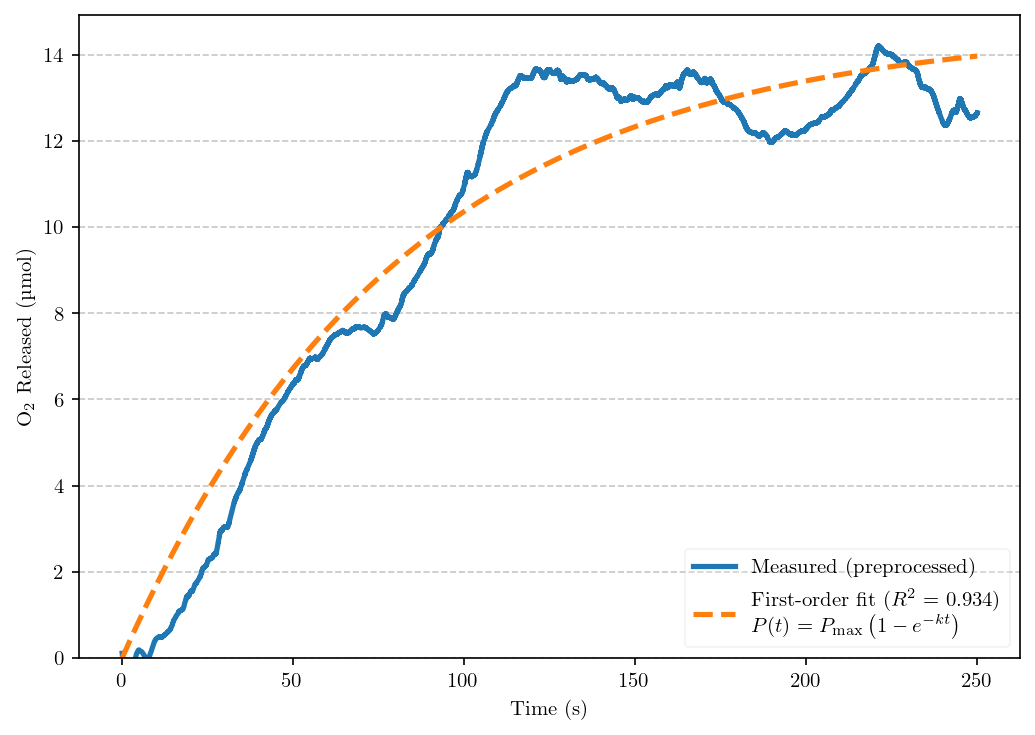

In [13]:

# ---- Load your preprocessed CSV ----
m1_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M1-2.5mM\data files\O2_RT_released_multi_volumes.csv"
df_m1 = pd.read_csv(m1_csv)
df_m1.columns = [c.strip() for c in df_m1.columns]

# Replace these with the series/column you want to fit
ngas_m1 = df_m1["O2 Released (µmol) - Vg=4.0mL"].values
time_m1 = df_m1["Time (s)"].values

# --- Clean: drop NaNs/Infs and ensure strictly increasing time (if needed) ---
mask = np.isfinite(time_m1) & np.isfinite(ngas_m1)
t = np.asarray(time_m1[mask], dtype=float)
y = np.asarray(ngas_m1[mask], dtype=float)

# If times are not strictly increasing, sort them (and y accordingly)
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y = t[order], y[order]

# Optionally, shift time to start at 0 for numerical stability (doesn't change k)
t0 = t.min()
t = t - t0

# --- First-order model ---
def first_order_model(t, P_max, k):
    # P(t) = P_max * (1 - exp(-k t))
    return P_max * (1.0 - np.exp(-k * t))

# --- Fit: robust initial guesses + nonnegative bounds ---
Pmax0 = float(np.nanmax(y))
dt = max(t.max() - t.min(), 1.0)  # seconds span; guard against zero
# choose half-life ~ 30% of data span as a reasonable default
k0 = np.log(2.0) / (0.3 * dt)
k0 = max(k0, 1e-9)

popt, pcov = curve_fit(
    first_order_model, t, y,
    p0=[Pmax0 if np.isfinite(Pmax0) and Pmax0 > 0 else (y[-1] if len(y) else 1.0), k0],
    bounds=([0.0, 0.0], [np.inf, np.inf]),
    maxfev=20000
)
P_max_fit, k_fit = popt
y_fit = first_order_model(t, *popt)

# --- Metrics (first-order only) ---
def aic(n, rss, k_params):
    return n * np.log(rss / n) + 2 * k_params

def bic(n, rss, k_params):
    return n * np.log(rss / n) + k_params * np.log(n)

n = len(y)
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
aic_val = aic(n, rss, 2)  # params: P_max, k
bic_val = bic(n, rss, 2)
t_half_s = np.log(2.0) / k_fit
t_half_h = t_half_s / 3600.0

# --- Show metrics ---
metrics = pd.DataFrame({
    "Model": ["First-order"],
    "P_max (µmol)": [P_max_fit],
    "k (1/s)": [k_fit],
    "Half-Life (s)": [t_half_s],
    "Half-Life (h)": [t_half_h],
    "RMSE (µmol)": [rmse],
    "R²": [r2],
    "AIC": [aic_val],
    "BIC": [bic_val],
})
display(metrics.round(6))

# --- Plot (Plot #3 analog: data + first-order fit only) ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t + t0, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t + t0, y_fit, "--", lw=2.5,
         label=fr"First-order fit ($R^2$ = {r2:.3f})" + "\n" + r"$P(t)=P_{\max}\left(1-e^{-kt}\right)$")
plt.xlabel("Time (s)")
plt.ylabel("O$_2$ Released (µmol)")
plt.xlim()
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()


# Logistic

# Gompertz

# M2 - 2.18mM @ RT

# First order

# Logistic

# Gompertz

# M2 - 2.18mM @ 37 C

# First order

# Logistic

# Gompertz

# M3 - 1.2mM @ RT

# First order

# Logistic

# Gompertz

# M3 - 1.2mM @ 37 C

# First order

# Logistic

# Gompertz